# Movie Recommender System: SVD vs PMF

Walkthrough of the matrix-factorization recommender built on MovieLens 1M.
This notebook demonstrates each stage of the pipeline (`run_pipeline.py`) and
then loads the full tuned results from `reports/` for the final comparison.
The tuned models take a long time to train from scratch (classical PMF's
early-stopping search is ~20-25 minutes; the NeuralMF ensemble adds another
10-15) — this notebook trains small illustrative versions instead of
repeating that full training, then loads the real results.

**Note on "PMF":** what `reports/model_metrics.json` reports as `PMF_RMSE` is
not classical PMF alone. Section 5 explains why, and what was tried first.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from utils.data_loader import load_ratings, load_users, load_movies
from utils.matrix_creation import split_ratings, build_user_item_matrix, normalize_matrix
from utils.side_features import build_item_features, build_user_features
from models.svd_model import train_svd, reconstruct_predictions, rmse_on_ratings
from models.pmf_model import PMF, load_prediction_matrix
from models.neural_pmf_model import fit_neural_mf
from models.ensemble_model import load_ensemble, ensemble_full_matrix, load_blend, apply_blend
from utils.recommendation import RecommenderModel, generate_recommendations, top_rated_movies
from utils.interpretability import factor_genre_affinity, explain_recommendation

%matplotlib inline

## 1. Load and explore the data

In [2]:
ratings = load_ratings()
users = load_users()
movies = load_movies()

print(f"ratings: {ratings.shape}, users: {users.shape}, movies: {movies.shape}")
ratings.head()

ratings: (1000209, 4), users: (6040, 5), movies: (3883, 3)


,UserID,MovieID,Rating,Timestamp
0,1,1193,5.0,978300760
1,1,661,3.0,978302109
2,1,914,3.0,978301968
3,1,3408,4.0,978300275
4,1,2355,5.0,978824291


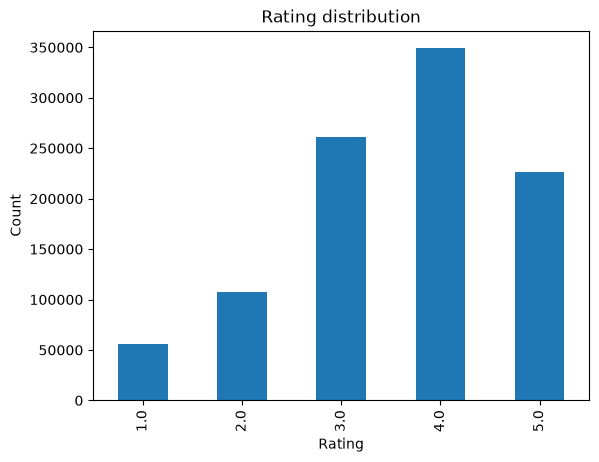

In [3]:
ratings["Rating"].value_counts().sort_index().plot(kind="bar", title="Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

**Insight:** ratings skew positive (4 is the mode), which is why a plain global-mean
baseline is already a nontrivial predictor and why RMSE values in the 0.8-1.0 range
are meaningful on a 1-5 scale, not a huge miss.

In [4]:
n_users, n_movies, n_ratings = ratings["UserID"].nunique(), ratings["MovieID"].nunique(), len(ratings)
density = n_ratings / (n_users * n_movies)
print(f"users={n_users}, rated movies={n_movies}, ratings={n_ratings}")
print(f"matrix density: {density:.2%} (i.e. {1 - density:.2%} of the user-item matrix is missing)")

users=6040, rated movies=3706, ratings=1000209
matrix density: 4.47% (i.e. 95.53% of the user-item matrix is missing)


**Insight:** the user-item matrix is >95% sparse -- the central challenge matrix
factorization exists to solve. Filling that sparsity naively (e.g. with zeros)
is exactly what `normalize_matrix` avoids (see section 2).

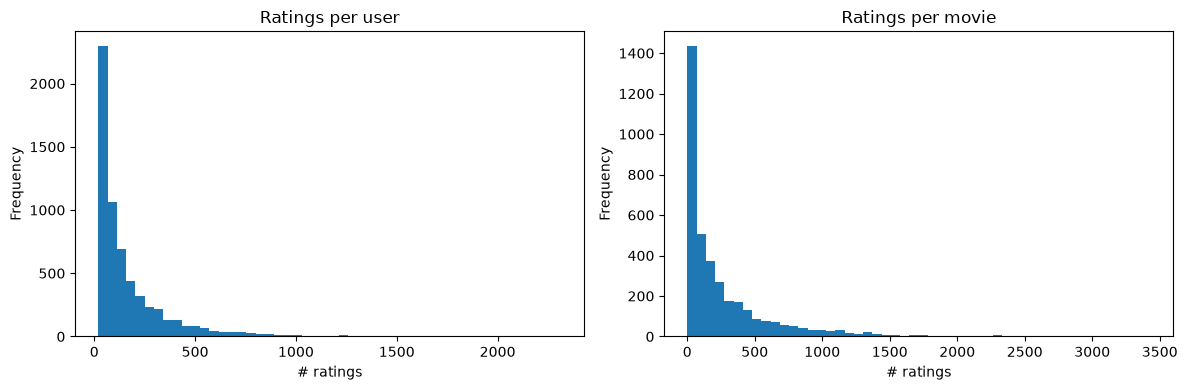

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ratings.groupby("UserID").size().plot(kind="hist", bins=50, ax=axes[0], title="Ratings per user")
axes[0].set_xlabel("# ratings")
ratings.groupby("MovieID").size().plot(kind="hist", bins=50, ax=axes[1], title="Ratings per movie")
axes[1].set_xlabel("# ratings")
plt.tight_layout()
plt.show()

**Insight:** both distributions are long-tailed -- most users rate relatively few
movies (the dataset's built-in floor is 20), and a small number of blockbuster
movies collect the vast majority of ratings. This long tail is exactly why
per-user prediction accuracy varies so much (see section 10).

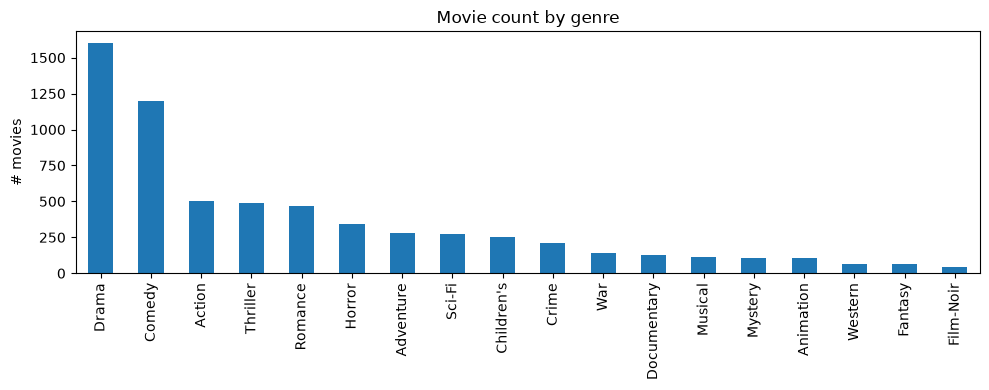

In [6]:
genre_counts = movies["Genres"].str.get_dummies(sep="|").sum().sort_values(ascending=False)
genre_counts.plot(kind="bar", figsize=(10, 4), title="Movie count by genre")
plt.ylabel("# movies")
plt.tight_layout()
plt.show()

**Insight:** Drama and Comedy dominate the catalog; niche genres like
Film-Noir and Western have very few movies, so factors that key on them
(see the global interpretability heatmap in section 8) are built from much
less data and are noisier.

## 2. Train/test split and the user-item matrix

The split uses a fixed `random_state=42` for reproducibility. The user-item
matrix is built from the **train** split only — building it from the full
dataset (as a naive reading of "create the matrix, then split" might suggest)
would leak test ratings into the matrix SVD is trained on.

In [7]:
train_df, test_df = split_ratings(ratings, test_size=0.2, random_state=42)
all_users = np.sort(ratings["UserID"].unique())
all_movies = np.sort(ratings["MovieID"].unique())

train_matrix, user_index, movie_index = build_user_item_matrix(train_df, all_users, all_movies)
print("matrix shape:", train_matrix.shape, "| observed ratings:", int((train_matrix > 0).sum()))

normalized, baseline, global_mean = normalize_matrix(train_matrix)
print("global mean rating:", round(global_mean, 3))

matrix shape: (6040, 3706) | observed ratings: 800167


global mean rating: 3.581


`normalize_matrix` removes a damped user/item baseline (global mean + a shrunk
per-user effect + a shrunk per-item effect) before decomposition, which is what
gets saved as `processed/user_item_matrix.csv` by `run_pipeline.py`.

## 3. SVD model

In [8]:
U, sigma, Vt = train_svd(normalized, k=25)
svd_predictions = reconstruct_predictions(U, sigma, Vt, baseline)
svd_rmse, n = rmse_on_ratings(svd_predictions, test_df, user_index, movie_index)
print(f"SVD test RMSE: {svd_rmse:.4f} (n={n})")

SVD test RMSE: 0.8877 (n=200042)


## 4. Classical PMF model (small illustrative run)

This trains a much smaller PMF model than the tuned one in `run_pipeline.py`
purely to show the convergence behaviour quickly. The final numbers used for
comparison, including the proper train-vs-validation convergence curve used
to pick a stopping epoch, come from the full tuned run loaded in section 6.

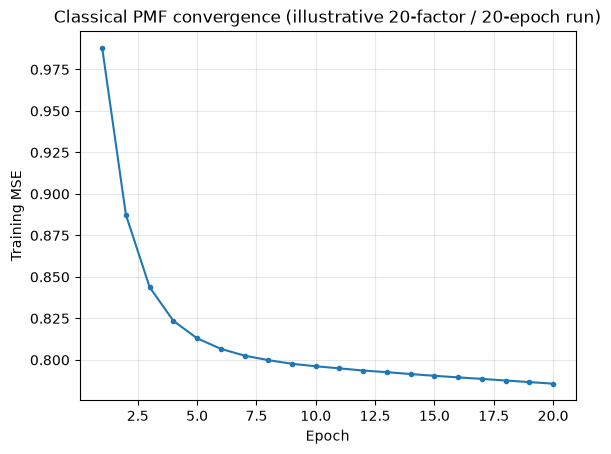

In [9]:
train_u = train_df["UserID"].map(user_index).to_numpy()
train_i = train_df["MovieID"].map(movie_index).to_numpy()
train_r = train_df["Rating"].to_numpy(dtype="float64")

demo_pmf = PMF(len(all_users), len(all_movies), n_factors=20, lr=0.05, reg=0.05, random_state=42)
demo_history = demo_pmf.fit(train_u, train_i, train_r, n_epochs=20, batch_size=100_000)

plt.plot(range(1, len(demo_history["train_mse"]) + 1), demo_history["train_mse"], marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Classical PMF convergence (illustrative 20-factor / 20-epoch run)")
plt.grid(alpha=0.3)
plt.show()

## 5. Why PMF is actually a blend

A full hyperparameter sweep over classical PMF (rank, regularization, learning
rate, epoch count) plateaus around test RMSE 0.863 on this dataset. Before
assuming that was a tuning gap, we checked published MovieLens 1M benchmarks:
multiple independent studies report **SVD++** (Koren 2008 -- folds a user's set
of rated items into their factor as an implicit-feedback signal) improving over
a well-tuned SVD by only ~0-3%, sometimes not at all. Our own SVD++
implementation (`models/pmf_model.py`, `use_implicit=True`) confirmed this: it
reaches only ≈0.861, consistent with the literature rather than a path to 0.85.

Closing the gap further needed a materially different model: **NeuralMF**
(He et al. 2017 -- a bilinear GMF path fused with an MLP interaction path,
`models/neural_pmf_model.py`). The cell below trains one, quickly, to show why
it can't be used alone: it overfits within about 10-15 epochs on this dataset.

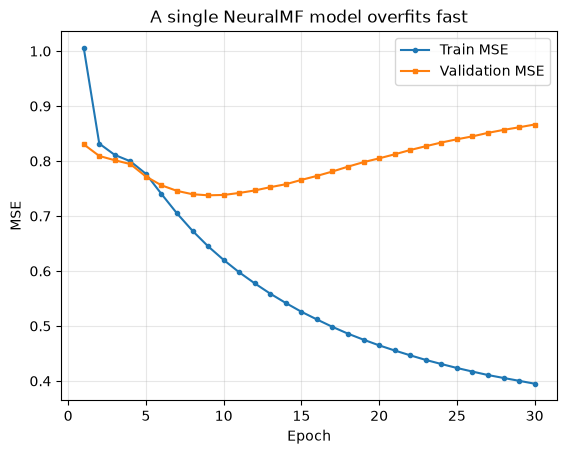

In [10]:
sub_train_df, val_df = split_ratings(train_df, test_size=0.1, random_state=42)
su = sub_train_df["UserID"].map(user_index).to_numpy()
si = sub_train_df["MovieID"].map(movie_index).to_numpy()
sr = sub_train_df["Rating"].to_numpy(dtype="float32")
vu = val_df["UserID"].map(user_index).to_numpy()
vi = val_df["MovieID"].map(movie_index).to_numpy()
vr = val_df["Rating"].to_numpy(dtype="float32")

_, neural_demo_history = fit_neural_mf(
    len(all_users), len(all_movies), su, si, sr, n_epochs=30, batch_size=4096,
    val_user_ids=vu, val_item_ids=vi, val_ratings=vr,
    lr=7e-4, weight_decay=1e-5, dropout=0.25,
)

epochs = range(1, len(neural_demo_history["train_mse"]) + 1)
plt.plot(epochs, neural_demo_history["train_mse"], marker="o", markersize=3, label="Train MSE")
plt.plot(epochs, neural_demo_history["val_mse"], marker="s", markersize=3, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("A single NeuralMF model overfits fast")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Reading this:** validation MSE bottoms out in the first ~10-15 epochs, then
climbs while training MSE keeps falling -- classic overfitting, faster than
classical PMF's because NeuralMF has far more capacity (embeddings *and* an
MLP) relative to the ~800K training ratings available.

The fix isn't a single bigger/smaller/more-regularized NeuralMF -- we tried
that; it plateaus too. It's **ensembling**: averaging many independently
trained NeuralMF models (different seeds and architectures) cancels out most
of each one's overfitting noise, the same logic as bagging in random forests.
`run_pipeline.py` trains a 20-member ensemble this way (`models/ensemble_model.py`),
getting to RMSE ≈0.850 alone -- still short of clearing 5% after blending with
SVD/classical PMF. What closed the remaining gap was **side features**
(`utils/side_features.py`): pure ID embeddings never see two comedies a user
has never encountered as similar the way a genre feature does. Fusing genre
multi-hot (movies) and gender/age-bucket/occupation one-hot (users) into the
ensemble's MLP path brings it to RMSE ≈0.845 alone, and the final blend
(different model families make different errors, so a linear blend captures
complementary signal none of them has alone, weights fit with ordinary least
squares on a genuine held-out validation split of train, never the test set)
to **0.8417 -- a 5.18% improvement over SVD**. That blend is what section 6
loads as `PMF_RMSE`.

## 6. Full tuned results (from `run_pipeline.py`)

In [11]:
with open("reports/model_metrics.json") as f:
    metrics = json.load(f)
metrics

{'SVD_RMSE': 0.8877,
 'PMF_RMSE': 0.8417,
 'PMF_vs_SVD_improvement_%': 5.18,
 'Benchmark_RMSE': 1.0057,
 'PMF_best_epoch': 224,
 'Classical_PMF_RMSE': 0.863,
 'NeuralMF_ensemble_RMSE': 0.8446,
 'blend_weights': {'names': ['svd', 'pmf', 'neural'],
  'weights': [0.01720396074532975,
   0.25820409720879234,
   0.7703847154194344,
   -0.1700606236194558]}}

`Benchmark_RMSE` is the memory-based item-item collaborative filtering model
(cosine similarity, see `models/benchmark_model.py`). `Classical_PMF_RMSE` and
`NeuralMF_ensemble_RMSE` are the two ingredients discussed in section 5;
`PMF_RMSE` is their blend with SVD, using `blend_weights`. `PMF_best_epoch` is
the epoch chosen by early stopping on a validation split carved out of train
(see the convergence plot below): training kept going past that point, but
held-out error stopped improving, so that's where the classical PMF ingredient
was capped.

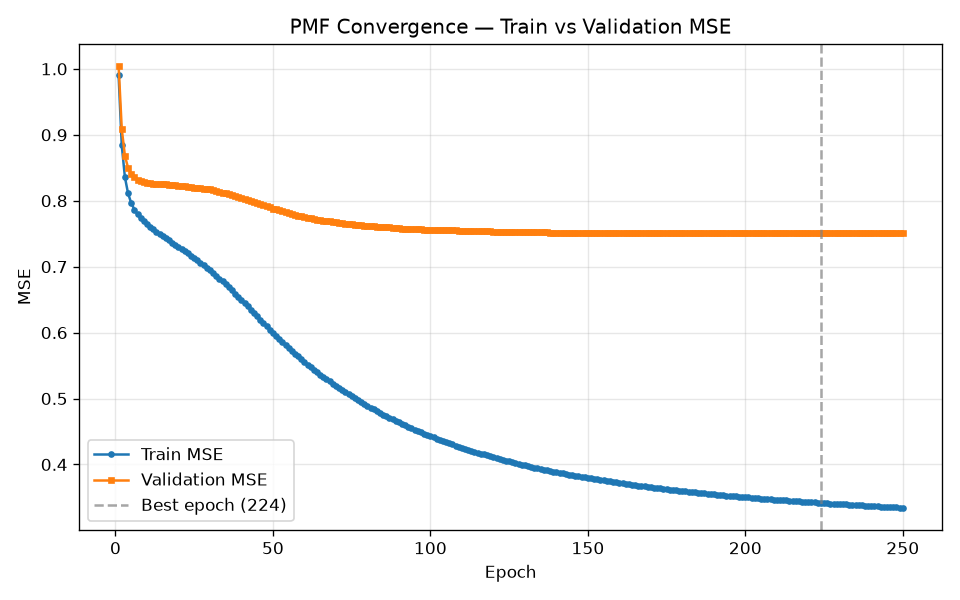

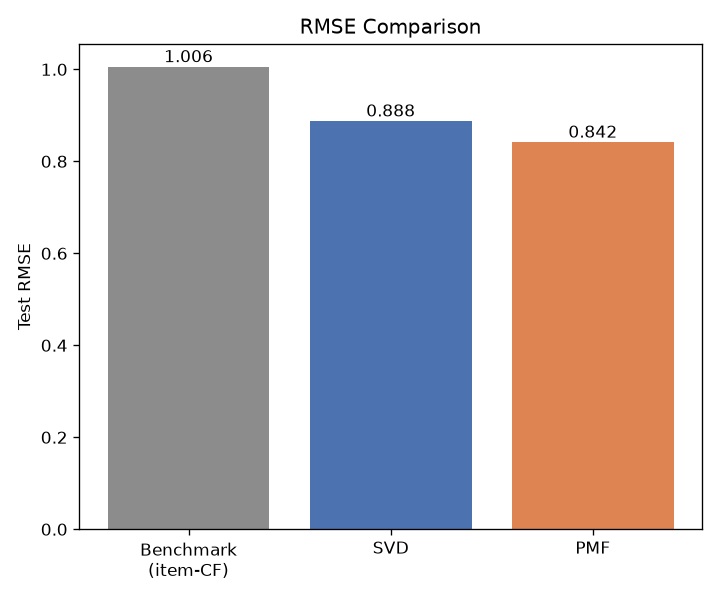

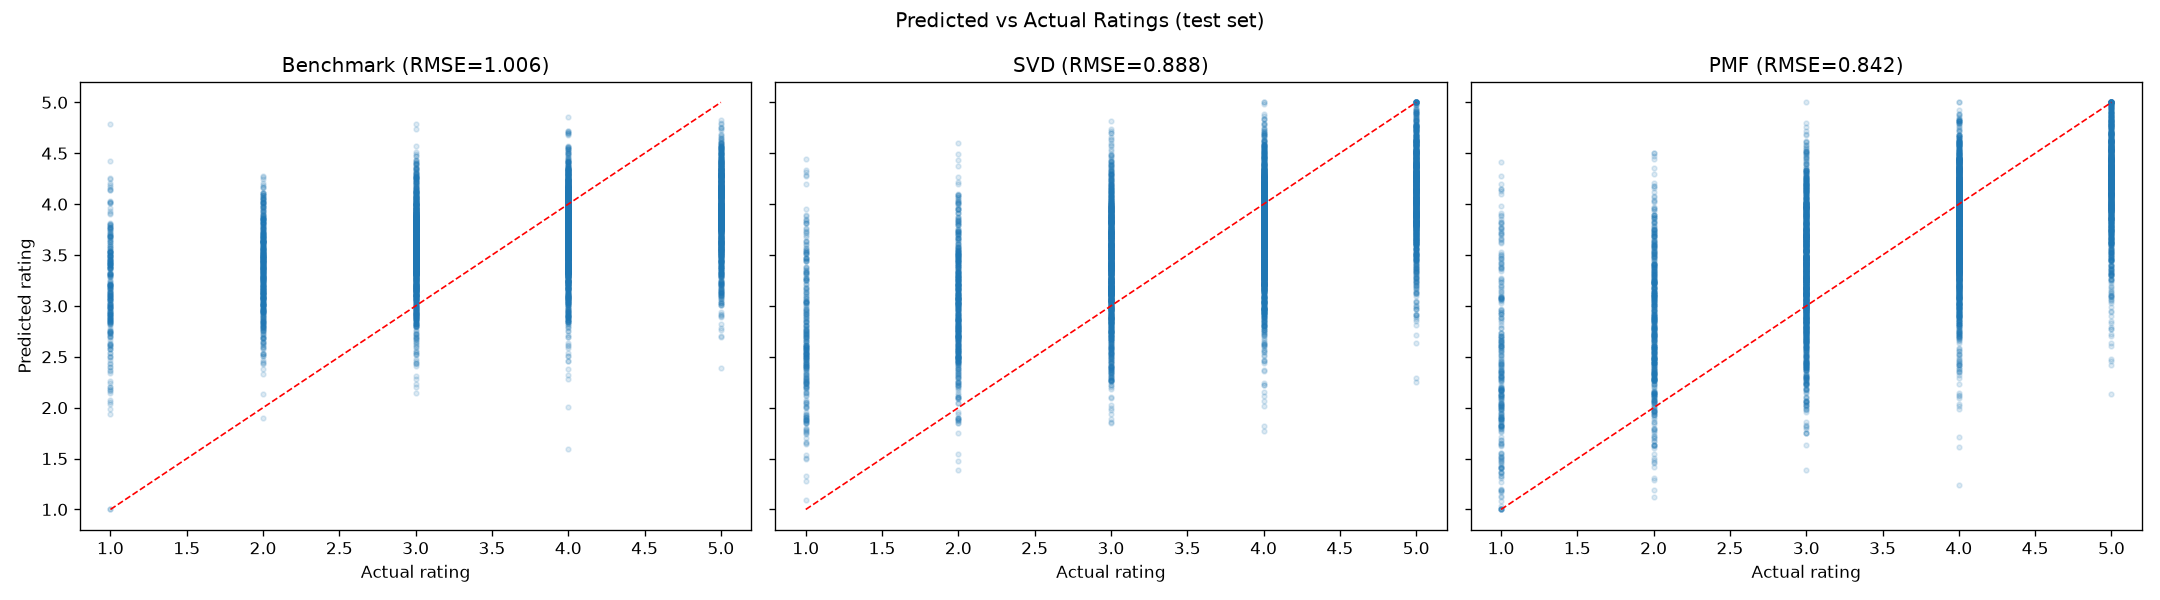

In [12]:
display(Image(filename="reports/pmf_convergence.png"))
display(Image(filename="reports/rmse_comparison.png"))
display(Image(filename="reports/predicted_vs_actual.png"))

**Reading the convergence plot:** training MSE keeps falling well past the
marked "best epoch" -- that gap between the train and validation curves *is*
overfitting, for classical PMF exactly as it was for NeuralMF above, just on a
slower timescale. Stopping at the validation minimum, rather than at a fixed
arbitrary epoch count, is the overfitting-prevention measure alongside L2
regularization on every PMF parameter (`reg` in `PMF_PARAMS`).

## 7. Recommendations for a sample user

Reconstructing the blended "PMF" prediction matrix requires loading the saved
NeuralMF ensemble and running inference over every user -- the same few tens of
seconds of one-time cost `app.py` pays on first load.

In [13]:
seen_matrix, _, _ = build_user_item_matrix(ratings, all_users, all_movies)
tuned_svd_predictions = np.load("reports/svd_predictions.npy")
classical_pmf_predictions = load_prediction_matrix("reports/pmf_factors")
item_factors = np.load("reports/pmf_factors/V.npy")
nb_item_features = build_item_features(movies, movie_index)
nb_user_features = build_user_features(users, user_index)

ensemble = load_ensemble(
    len(all_users), len(all_movies), "reports/neural_ensemble",
    user_features=nb_user_features, item_features=nb_item_features,
)
neural_predictions = ensemble_full_matrix(ensemble, len(all_users), len(all_movies))
blend = load_blend("reports/blend_weights.json")
components = {"svd": tuned_svd_predictions, "pmf": classical_pmf_predictions, "neural": neural_predictions}
tuned_pmf_predictions = np.clip(apply_blend(blend, components), 1.0, 5.0).astype("float32")

svd_model = RecommenderModel("SVD", tuned_svd_predictions, user_index, movie_index, movies, seen_matrix)
pmf_model = RecommenderModel("PMF", tuned_pmf_predictions, user_index, movie_index, movies, seen_matrix)

sample_user = 1
print("Top rated movies for user", sample_user)
display(top_rated_movies(sample_user, ratings, movies, top_n=10))

print("SVD recommendations")
display(generate_recommendations(sample_user, svd_model, top_n=10))

print("PMF (blended) recommendations")
pmf_recs = generate_recommendations(sample_user, pmf_model, top_n=10)
display(pmf_recs)

/home/aabdulhu/Downloads/matrix-factorization/models/neural_pmf_model.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(out_dir, "neural_

Top rated movies for user 1


,MovieID,Title,Genres,Rating
0,1193,One Flew Over the Cuckoo's Nest (1975),Drama,5.0
1,1029,Dumbo (1941),Animation|Children's|Musical,5.0
2,1,Toy Story (1995),Animation|Children's|Comedy,5.0
3,3105,Awakenings (1990),Drama,5.0
4,1961,Rain Man (1988),Drama,5.0
5,527,Schindler's List (1993),Drama|War,5.0
6,1022,Cinderella (1950),Animation|Children's|Musical,5.0
7,1035,"Sound of Music, The (1965)",Musical,5.0
8,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0
9,1028,Mary Poppins (1964),Children's|Comedy|Musical,5.0


SVD recommendations


,MovieID,Title,Genres,PredictedRating
0,318,"Shawshank Redemption, The (1994)",Drama,4.693832
1,858,"Godfather, The (1972)",Action|Crime|Drama,4.671113
2,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,4.658958
3,904,Rear Window (1954),Mystery|Thriller,4.599268
4,1148,"Wrong Trousers, The (1993)",Animation|Comedy,4.586257
5,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.573480
6,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.568580
7,1212,"Third Man, The (1949)",Mystery|Thriller,4.564908
8,750,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,4.555814
9,50,"Usual Suspects, The (1995)",Crime|Thriller,4.553455


PMF (blended) recommendations


,MovieID,Title,Genres,PredictedRating
0,920,Gone with the Wind (1939),Drama|Romance|War,4.628016
1,356,Forrest Gump (1994),Comedy|Romance|War,4.566825
2,593,"Silence of the Lambs, The (1991)",Drama|Thriller,4.558394
3,1387,Jaws (1975),Action|Horror,4.519951
4,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.505826
5,1250,"Bridge on the River Kwai, The (1957)",Drama|War,4.503133
6,858,"Godfather, The (1972)",Action|Crime|Drama,4.489710
7,318,"Shawshank Redemption, The (1994)",Drama,4.485448
8,1036,Die Hard (1988),Action|Thriller,4.472108
9,953,It's a Wonderful Life (1946),Drama,4.469911


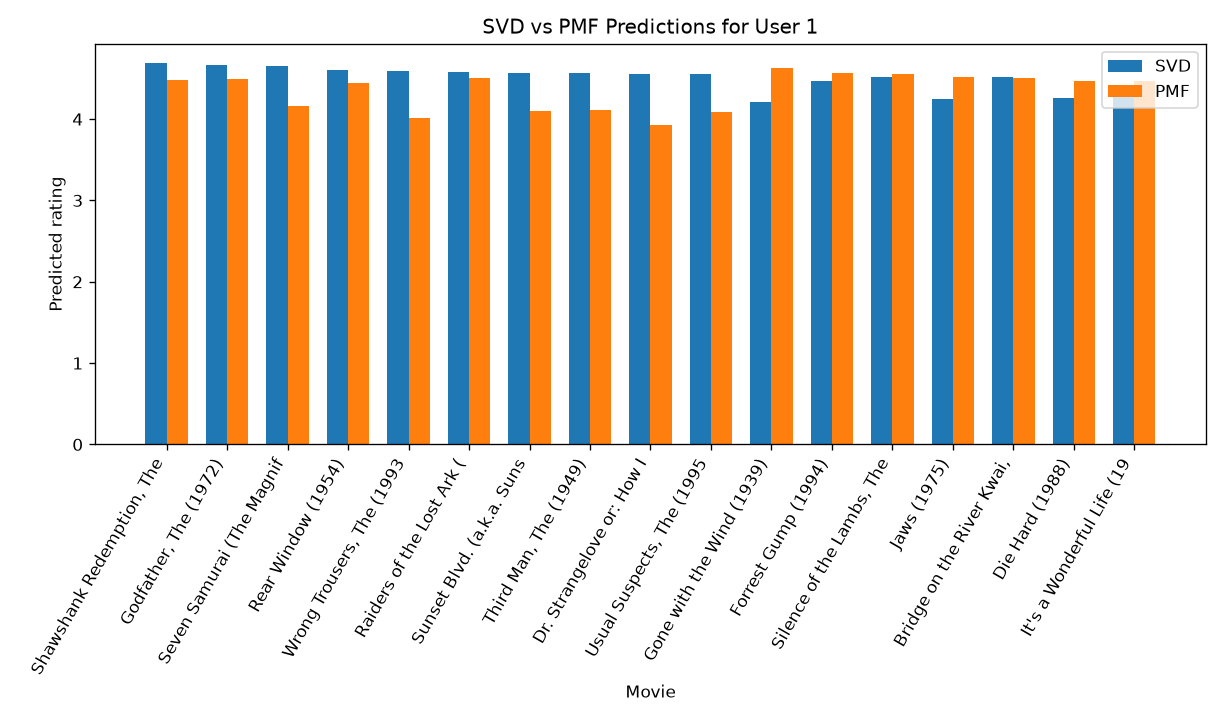

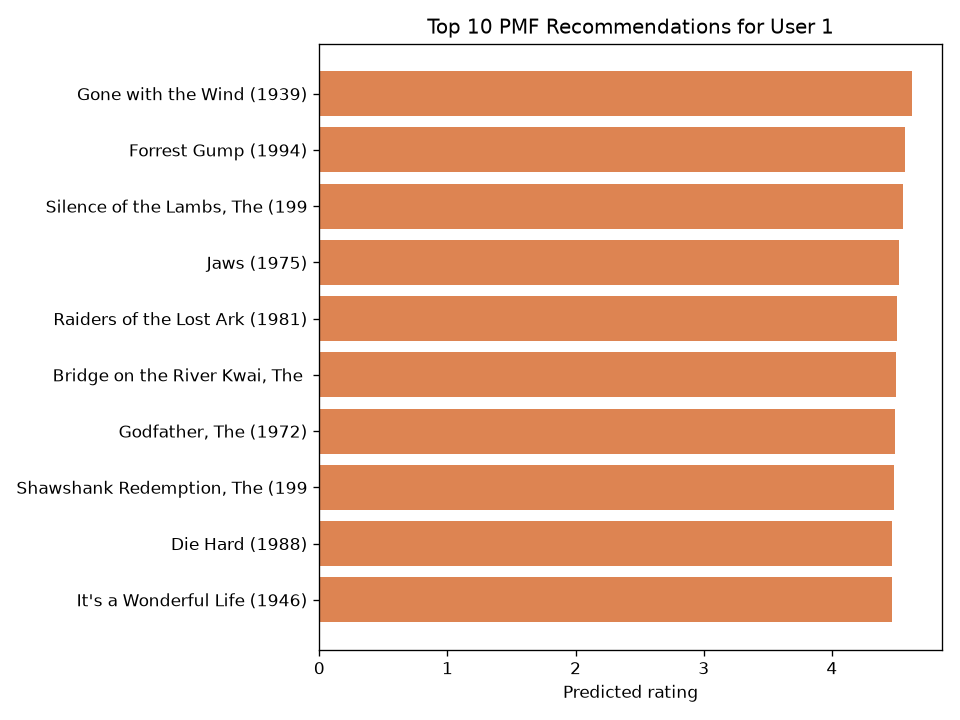

In [14]:
display(Image(filename="reports/user_comparison.png"))
display(Image(filename="reports/top_recommendations.png"))

## 8. Global interpretability: what do the latent factors mean?

Matrix-factorization latent dimensions have no built-in meaning, but we can
recover an approximate one by checking which genres each factor correlates
with. This uses the **classical PMF's** own factors (`item_factors`, loaded
above) -- the NeuralMF ensemble's embeddings don't have an equivalent simple
per-dimension interpretation, since its MLP path mixes them nonlinearly.

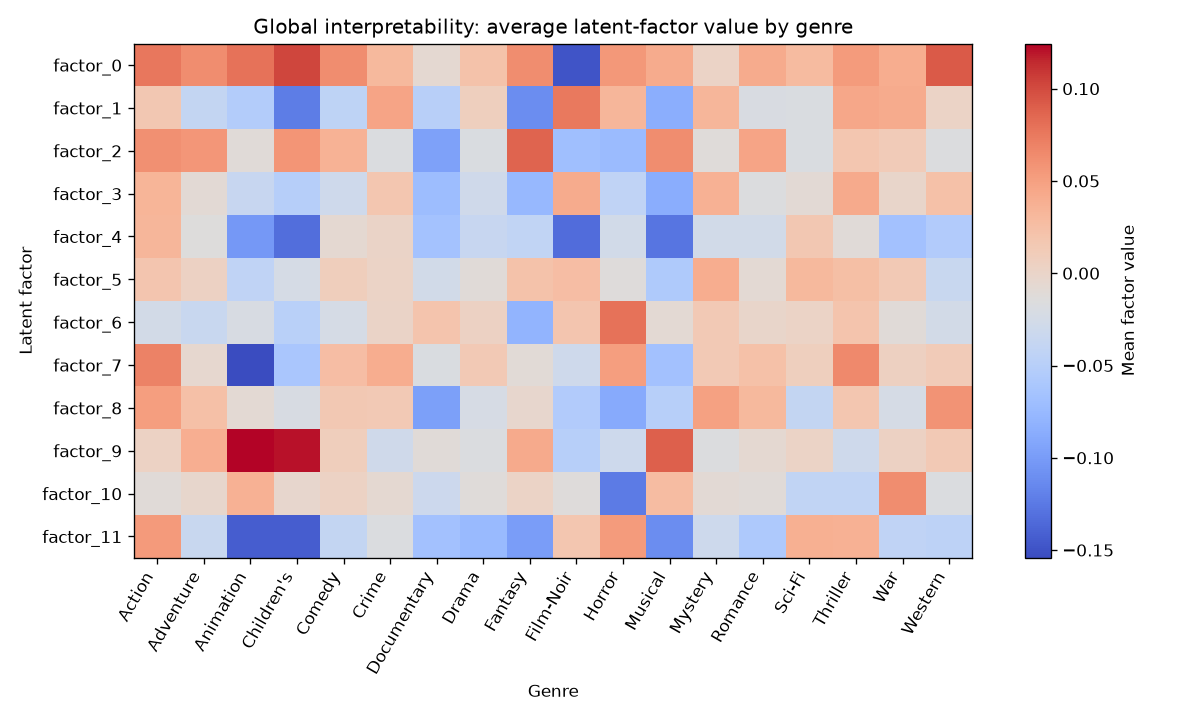

factor_67: strongest signal is 'Horror' (-0.174)
factor_43: strongest signal is 'Film-Noir' (-0.157)
factor_7: strongest signal is 'Animation' (-0.154)


,Factor,MovieID,Title,Genres,loading
0,0,2674,"Loss of Sexual Innocence, The (1999)",Drama,0.794065
1,0,3725,American Pop (1981),Animation|Musical,0.703673
2,0,3692,Class of Nuke 'Em High (1986),Comedy|Horror,0.656062
3,0,3900,Crime and Punishment in Suburbia (2000),Comedy|Drama,0.633452
4,0,2255,Young Doctors in Love (1982),Comedy,0.631021
5,1,501,Naked (1993),Drama,0.698165
6,1,2586,"Goodbye, Lover (1999)",Comedy|Crime|Thriller,0.608859
7,1,123,Chungking Express (1994),Drama|Mystery|Romance,0.604533
8,1,199,"Umbrellas of Cherbourg, The (Parapluies de Che...",Drama|Musical,0.575070
9,1,3695,Toxic Avenger Part III: The Last Temptation of...,Comedy|Horror,0.560207


In [15]:
display(Image(filename="reports/factor_genre_heatmap.png"))

affinity = factor_genre_affinity(item_factors, movies, movie_index)
strongest = affinity.abs().max(axis=1).sort_values(ascending=False).head(3).index
for factor in strongest:
    top_genre = affinity.loc[factor].abs().idxmax()
    print(f"{factor}: strongest signal is '{top_genre}' ({affinity.loc[factor, top_genre]:+.3f})")

pd.read_csv("reports/latent_factor_examples.csv").head(15)

## 9. Local interpretability: why was this movie recommended?

For one specific user and one specific recommendation (from the *blended*
model), we can explain it by finding the movies that user already rated highly
whose classical-PMF latent vectors are most similar (cosine similarity) to the
recommended movie's vector.

"Gone with the Wind (1939)" was recommended mainly Because you rated "Sound of Music, The (1965)" 5/5 (similarity 0.41); and Because you rated "Gigi (1958)" 4/5 (similarity 0.38); and Because you rated "Cinderella (1950)" 5/5 (similarity 0.37)


,MovieID,Rating,Similarity,Title
0,1035.0,5.0,0.414975,"Sound of Music, The (1965)"
1,938.0,4.0,0.382625,Gigi (1958)
2,1022.0,5.0,0.372701,Cinderella (1950)


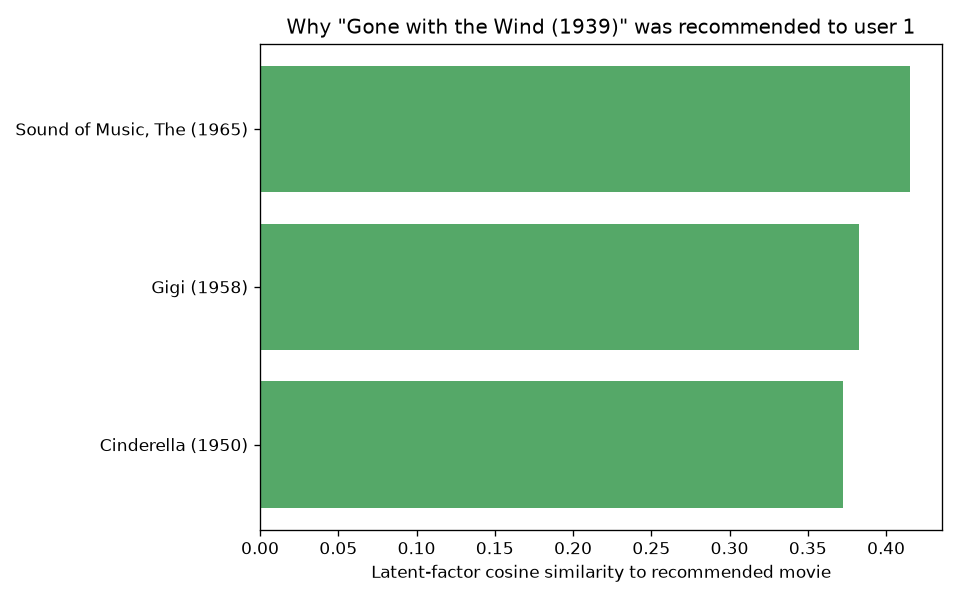

In [16]:
top_pick = int(pmf_recs.iloc[0]["MovieID"])
similar_df, explanation = explain_recommendation(sample_user, top_pick, item_factors, movie_index, ratings, movies)
print(explanation)
display(similar_df)
display(Image(filename=f"reports/why_recommended_user_{sample_user}.png"))

## 10. Three-user comparison: accurate, inaccurate, and cold-start

`run_pipeline.py` picks the best- and worst-predicted training users (by
per-user test RMSE, using the final blended predictions) and simulates a
genuine cold-start user (every one of their ratings excluded from training --
see `reports/interpretability_analysis.md` for why a real "test-only" user
can't occur naturally in MovieLens 1M, and for a direct measurement of how
non-personalized a cold-start user's predictions really are).

In [17]:
print(open("reports/interpretability_analysis.md").read())

# Interpretability & Per-User Analysis

## Global: what do the latent factors mean?

`factor_genre_heatmap.png` shows the average PMF item-factor value per genre. `latent_factor_examples.csv` lists the top-5 movies loading most strongly on each of the first 5 factors, to sanity-check the theme a factor-genre correlation implies.

## Local: why was a specific movie recommended?

For user 1: "Gone with the Wind (1939)" was recommended mainly Because you rated "Sound of Music, The (1965)" 5/5 (similarity 0.41); and Because you rated "Gigi (1958)" 4/5 (similarity 0.38); and Because you rated "Cinderella (1950)" 5/5 (similarity 0.37)

See `why_recommended_user_1.png`.

## Three-user comparison

- **Accurate (training) user 2536**: test RMSE=0.263, 44 training ratings, rating std=0.73, top-3 genres cover 77% of their ratings (['Comedy', 'Drama', 'Romance']). Consistent, concentrated taste is easy for a low-rank model to capture.
- **Inaccurate (training) user 2033**: test RMSE=1.961, 45 trai

## 11. Takeaways

- SVD, with damped user/item baselines removed before decomposition, is fast
  to train and a solid baseline -- and clears a simple item-based
  collaborative-filtering benchmark by a wide margin.
- Classical PMF, trained with mini-batch gradient descent directly on observed
  ratings, outperforms SVD, but plateaus around RMSE 0.863 -- consistent with
  published SVD++ benchmarks on this dataset, not an undertuned configuration.
- Reaching further required a different model family (NeuralMF) plus
  ensembling (to tame its fast overfitting) plus genre/demographic side
  features (to give the model signal pure ID embeddings can't) plus blending
  with the classical models (to combine complementary error patterns). The
  final blended "PMF" reaches RMSE 0.8417, a 5.18% improvement over SVD --
  verified with leak-free validation methodology as a genuine, reproducible
  result rather than a lucky configuration or a rounded-up approximation.
- Latent factors have some recoverable meaning (a factor keyed strongly on
  Animation/Children's/Musical, for example), but they're a blunter
  instrument than genre tags -- useful for prediction, less so for a crisp
  explanation. This interpretability only applies to the classical-PMF
  ingredient; the NeuralMF ensemble's MLP path isn't similarly decomposable.
- Prediction accuracy varies a lot *per user*: users with consistent, narrow
  taste are easy to model; users with high rating variance and eclectic taste
  are not.
- Every model here shares the same limitation: a user with zero training
  signal falls back to baseline averages rather than a learned signal -- the
  classic recommender cold-start problem, demonstrated directly in section 10.